# Pizza Sales Analysis Using Python

**Tools:** Python, pandas, Matplotlib, Seaborn  
**Focus:** Order‑level sales analysis and product insights


## Business Problem

The goal of this project is to analyze pizza sales data to understand:
- Customer ordering behavior
- Product performance
- Time-based sales trends

All metrics are calculated at the **order level** to avoid common aggregation errors.

## Data Understanding

Each row in the dataset represents a **pizza line item**, not a complete order.
As multiple pizzas can appear within the same order, aggregation by `Order_id` is required
to avoid incorrect averages and inflated metrics.

## Feature Engineering

Additional columns were created to support time‑based analysis and proper sorting:
- `order_hour` for hourly trends
- `day_number` and `month_number` to prevent alphabetical sorting errors

## Key Metrics

- **Total Revenue**
- **Total Orders (Distinct Order IDs)**
- **Average Order Value (AOV)**
- **Average Quantity per Order**

All metrics are validated using totals and distinct counts.

In [6]:
import pandas as pd
import numpy as np

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="Set2",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [10]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Pizza_id           48620 non-null  int64         
 1   Order_id           48620 non-null  int64         
 2   Pizza_name_id      48620 non-null  object        
 3   Quantity           48620 non-null  int64         
 4   Order_date         48620 non-null  datetime64[ns]
 5   Order_time         48620 non-null  object        
 6   Unit_price         48620 non-null  float64       
 7   Total_price        48620 non-null  float64       
 8   Pizza_size         48620 non-null  object        
 9   Pizza_category     48620 non-null  object        
 10  Pizza_ingredients  48620 non-null  object        
 11  Pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


,Pizza_id,Order_id,Pizza_name_id,Quantity,Order_date,Order_time,Unit_price,Total_price,Pizza_size,Pizza_category,Pizza_ingredients,Pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [12]:
df.head(10)

,Pizza_id,Order_id,Pizza_name_id,Quantity,Order_date,Order_time,Unit_price,Total_price,Pizza_size,Pizza_category,Pizza_ingredients,Pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
5,6,2,thai_ckn_l,1,2015-01-01,11:57:40,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
6,7,3,ital_supr_m,1,2015-01-01,12:12:28,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
7,8,3,prsc_argla_l,1,2015-01-01,12:12:28,20.75,20.75,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
8,9,4,ital_supr_m,1,2015-01-01,12:16:31,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
9,10,5,ital_supr_m,1,2015-01-01,12:21:30,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza


In [13]:
df.shape

(48620, 12)

In [2]:
import pandas as pd

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel("C:/Users/IsaacOgbaji/Downloads/pizza_sales.xlsx")

In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.head()

,Pizza_id,Order_id,Pizza_name_id,Quantity,Order_date,Order_time,Unit_price,Total_price,Pizza_size,Pizza_category,Pizza_ingredients,Pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [8]:
df.shape

(48620, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Pizza_id           48620 non-null  int64         
 1   Order_id           48620 non-null  int64         
 2   Pizza_name_id      48620 non-null  object        
 3   Quantity           48620 non-null  int64         
 4   Order_date         48620 non-null  datetime64[ns]
 5   Order_time         48620 non-null  object        
 6   Unit_price         48620 non-null  float64       
 7   Total_price        48620 non-null  float64       
 8   Pizza_size         48620 non-null  object        
 9   Pizza_category     48620 non-null  object        
 10  Pizza_ingredients  48620 non-null  object        
 11  Pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


In [13]:
df["Order_date"] = pd.to_datetime(df["Order_date"])

In [14]:
df["Order_time"] = pd.to_datetime(df["Order_time"], format="%H:%M:%S").dt.time

In [16]:
total_rows = len(df)
unique_orders = df["Order_id"].nunique()

total_rows, unique_orders

(48620, 21350)

Total Revenue

In [18]:
total_revenue = df["Total_price"].sum()
total_revenue

np.float64(817860.0499999999)

Total Orders

In [19]:
total_orders = df["Order_id"].nunique()
total_orders

21350

using this method wont be correct

In [21]:
df["Quantity"].mean()

np.float64(1.0196215549156726)

best method to arrive at the avearge is to create Order Level table

In [22]:
order_summary = (
    df
    .groupby("Order_id", as_index=False)
    .agg(
        total_quantity=("Quantity", "sum"),
        total_revenue=("Total_price", "sum")
    )
)

AVERAGE QUANTITY PER ORDER

In [24]:
avg_quantity_per_order = order_summary["total_quantity"].mean()
avg_quantity_per_order

np.float64(2.321967213114754)

Let's verify with totals

In [26]:
df["Quantity"].sum() / df["Order_id"].nunique()

np.float64(2.321967213114754)

AVERAGE ORDER VALUE (AOV)

In [27]:
avg_order_value = order_summary["total_revenue"].mean()
avg_order_value

np.float64(38.30726229508197)

OR

In [28]:
total_revenue / total_orders

np.float64(38.30726229508196)

TIME‑BASED ANALYSIS

In [ ]:
Order Hour

In [31]:
df["order_hour"] = pd.to_datetime(df["Order_time"], format="%H:%M:%S").dt.hour

Day of Week (Name)

In [32]:
df["day_of_week"] = df["Order_date"].dt.day_name()

Day Number (FOR SORTING)

In [33]:
df["day_number"] = df["Order_date"].dt.weekday + 1

Month Name

In [34]:
df["month"] = df["Order_date"].dt.month_name()

Month Number (FOR SORTING)

In [35]:
df["month_number"] = df["Order_date"].dt.month

MONTHLY REVENUE TREND

In [37]:
df.columns

Index(['Pizza_id', 'Order_id', 'Pizza_name_id', 'Quantity', 'Order_date',
       'Order_time', 'Unit_price', 'Total_price', 'Pizza_size',
       'Pizza_category', 'Pizza_ingredients', 'Pizza_name', 'order_date',
       'order_hour', 'day_of_week', 'day_number', 'month', 'month_number'],
      dtype='object')

In [38]:
day_revenue = (
    df.groupby(["day_number", "day_of_week"], as_index=False)
      .agg(total_revenue=("Total_price", "sum"))
      .sort_values("day_number")
)

In [39]:
monthly_revenue = (
    df.groupby(["month_number", "month"], as_index=False)
      .agg(total_revenue=("Total_price", "sum"))
      .sort_values("month_number")
)

ORDER VOLUME BY HOUR

Order count by hour

In [40]:
hourly_orders = (
    df.groupby("order_hour", as_index=False)
      .agg(total_orders=("Order_id", "nunique"))
)

In [41]:
hourly_orders.sort_values("total_orders", ascending=False).head()

,order_hour,total_orders
3,12,2520
4,13,2455
9,18,2399
8,17,2336
10,19,2009


PRODUCT ANALYSIS

In [42]:
df.columns

Index(['Pizza_id', 'Order_id', 'Pizza_name_id', 'Quantity', 'Order_date',
       'Order_time', 'Unit_price', 'Total_price', 'Pizza_size',
       'Pizza_category', 'Pizza_ingredients', 'Pizza_name', 'order_date',
       'order_hour', 'day_of_week', 'day_number', 'month', 'month_number'],
      dtype='object')

OP‑SELLING PIZZAS (BY QUANTITY)

In [43]:
top_pizzas = (
    df.groupby("Pizza_name", as_index=False)
      .agg(
          total_quantity=("Quantity", "sum"),
          total_revenue=("Total_price", "sum"),
          total_orders=("Order_id", "nunique")
      )
      .sort_values("total_quantity", ascending=False)
)

Top 10 Best‑Selling Pizzas

In [44]:
top_10_pizzas = top_pizzas.head(10)
top_10_pizzas

,Pizza_name,total_quantity,total_revenue,total_orders
7,The Classic Deluxe Pizza,2453,38180.50,2329
0,The Barbecue Chicken Pizza,2432,42768.00,2273
12,The Hawaiian Pizza,2422,32273.25,2280
20,The Pepperoni Pizza,2418,30161.75,2278
30,The Thai Chicken Pizza,2371,43434.25,2225
4,The California Chicken Pizza,2370,41409.50,2197
23,The Sicilian Pizza,1938,30940.50,1820
26,The Spicy Italian Pizza,1924,34831.25,1822
25,The Southwest Chicken Pizza,1917,34705.75,1825
1,The Big Meat Pizza,1914,22968.00,1811


These pizzas drive the highest sales volume and should be prioritized for menu positioning, inventory planning, and promotions.

PIZZA CATEGORY ANALYSIS

In [45]:
category_analysis = (
    df.groupby("Pizza_category", as_index=False)
      .agg(
          total_revenue=("Total_price", "sum"),
          total_quantity=("Quantity", "sum"),
          total_orders=("Order_id", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

In [46]:
category_analysis

,Pizza_category,total_revenue,total_quantity,total_orders
1,Classic,220053.10,14888,10859
2,Supreme,208197.00,11987,9085
0,Chicken,195919.50,11050,8536
3,Veggie,193690.45,11649,8941


PIZZA SIZE ANALYSIS

What pizza sizes do customers prefer?

In [48]:
size_analysis = (
    df.groupby("Pizza_size", as_index=False)
      .agg(
          total_orders=("Order_id", "nunique"),
          total_quantity=("Quantity", "sum"),
          total_revenue=("Total_price", "sum")
      )
      .sort_values("total_orders", ascending=False)
)

In [49]:
size_analysis

,Pizza_size,total_orders,total_quantity,total_revenue
0,L,12736,18956,375318.70
1,M,11159,15635,249382.25
2,S,10490,14403,178076.50
3,XL,544,552,14076.00
4,XXL,28,28,1006.60


TOP PIZZAS BY MONTH

Aggregate by Month + Pizza

In [51]:
pizza_monthly = (
    df.groupby(
        ["month_number", "month", "Pizza_name"],
        as_index=False
    )
    .agg(
        total_quantity=("Quantity", "sum"),
        total_revenue=("Total_price", "sum")
    )
    .sort_values(["month_number", "total_quantity"], ascending=[True, False])
)

Top 5 Pizzas per Month

In [52]:
top_pizzas_by_month = (
    pizza_monthly
    .groupby("month")
    .head(5)
)

PIZZA CATEGORY PERFORMANCE BY MONTH

In [53]:
category_monthly = (
    df.groupby(
        ["month_number", "month", "Pizza_category"],
        as_index=False
    )
    .agg(
        total_revenue=("Total_price", "sum"),
        total_quantity=("Quantity", "sum"),
        total_orders=("Order_id", "nunique")
    )
    .sort_values("month_number")
)

In [54]:
category_monthly

,month_number,month,Pizza_category,total_revenue,total_quantity,total_orders
0,1,January,Chicken,16188.75,913,714
1,1,January,Classic,18619.40,1257,920
2,1,January,Supreme,17929.75,1044,779
3,1,January,Veggie,17055.40,1018,774
4,2,February,Chicken,15468.25,875,674
5,2,February,Classic,17336.10,1178,871
6,2,February,Supreme,16718.85,964,720
7,2,February,Veggie,15636.40,944,723
8,3,March,Chicken,17625.50,994,764
9,3,March,Classic,18116.60,1236,917


PIZZA SIZE TRENDS OVER TIME

In [55]:
size_monthly = (
    df.groupby(
        ["month_number", "month", "Pizza_size"],
        as_index=False
    )
    .agg(
        total_orders=("Order_id", "nunique"),
        total_quantity=("Quantity", "sum"),
        total_revenue=("Total_price", "sum")
    )
    .sort_values("month_number")
)

In [56]:
size_monthly

,month_number,month,Pizza_size,total_orders,total_quantity,total_revenue
0,1,January,L,1098,1640,32399.40
1,1,January,M,938,1311,20943.50
2,1,January,S,898,1229,15103.50
3,1,January,XL,50,50,1275.00
4,1,January,XXL,2,2,71.90
5,2,February,L,1020,1521,30077.90
6,2,February,M,874,1210,19263.00
7,2,February,S,868,1189,14741.85
8,2,February,XL,38,38,969.00
9,2,February,XXL,3,3,107.85


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

 MONTHLY REVENUE TREND (LINE CHART)

How does revenue change across months?

In [60]:
monthly_revenue

,month_number,month,total_revenue
0,1,January,69793.30
1,2,February,65159.60
2,3,March,70397.10
3,4,April,68736.80
4,5,May,71402.75
5,6,June,68230.20
6,7,July,72557.90
7,8,August,68278.25
8,9,September,64180.05
9,10,October,64027.60


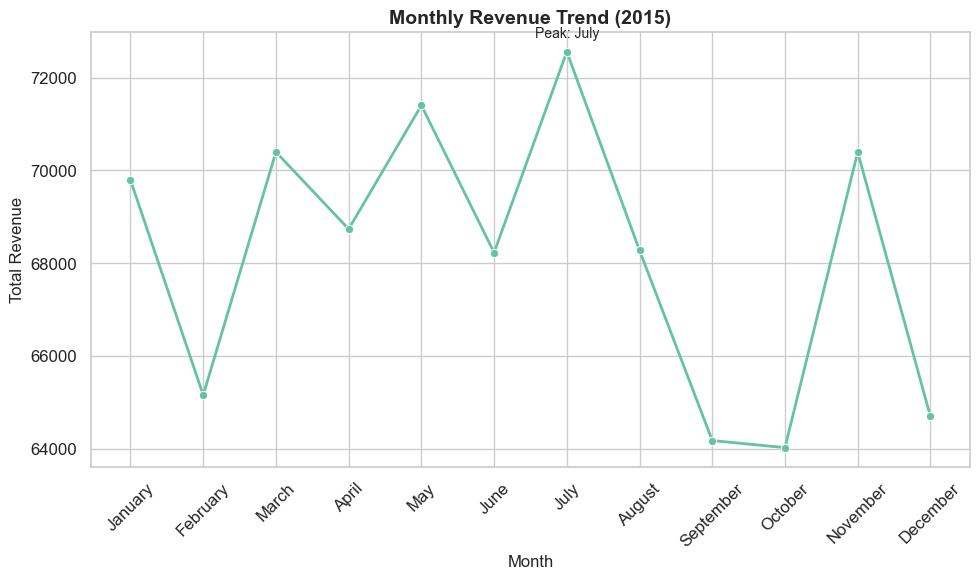

In [71]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="total_revenue",
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend (2015)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

# Annotate peak month
max_row = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmax()]
plt.annotate(
    f"Peak: {max_row['month']}",
    xy=(max_row["month"], max_row["total_revenue"]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

REVENUE BY PIZZA CATEGORY OVER TIME

Plot Category Revenue by Month

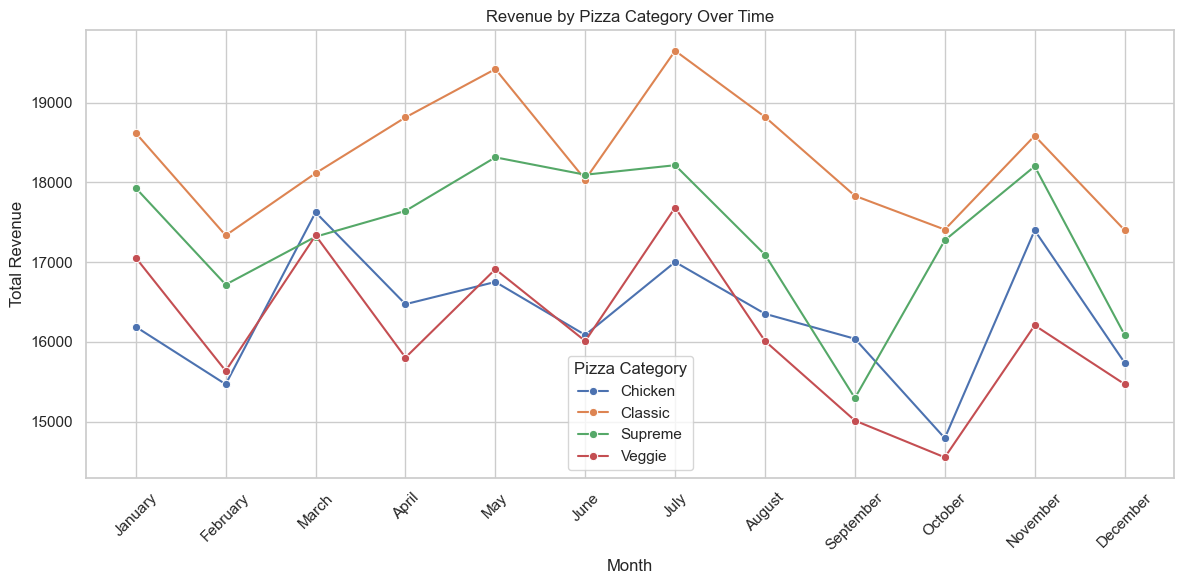

In [62]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=category_monthly,
    x="month",
    y="total_revenue",
    hue="Pizza_category",
    marker="o"
)

plt.title("Revenue by Pizza Category Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.legend(title="Pizza Category")
plt.tight_layout()
plt.show()

TOP 5 PIZZAS PER MONTH (FACET BAR CHART)

USE top_pizzas_by_month

In [63]:
top_pizzas_by_month

,month_number,month,Pizza_name,total_quantity,total_revenue
20,1,January,The Pepperoni Pizza,239,3001.25
0,1,January,The Barbecue Chicken Pizza,211,3770.25
4,1,January,The California Chicken Pizza,202,3471.50
30,1,January,The Thai Chicken Pizza,199,3657.25
23,1,January,The Sicilian Pizza,191,2987.75
52,2,February,The Pepperoni Pizza,205,2554.25
36,2,February,The California Chicken Pizza,204,3537.00
44,2,February,The Hawaiian Pizza,198,2633.00
32,2,February,The Barbecue Chicken Pizza,193,3416.75
39,2,February,The Classic Deluxe Pizza,173,2705.00


In [66]:
top_pizzas_by_month = (
    top_pizzas_by_month
    .sort_values(["month_number", "total_quantity"], ascending=[True, False])
)

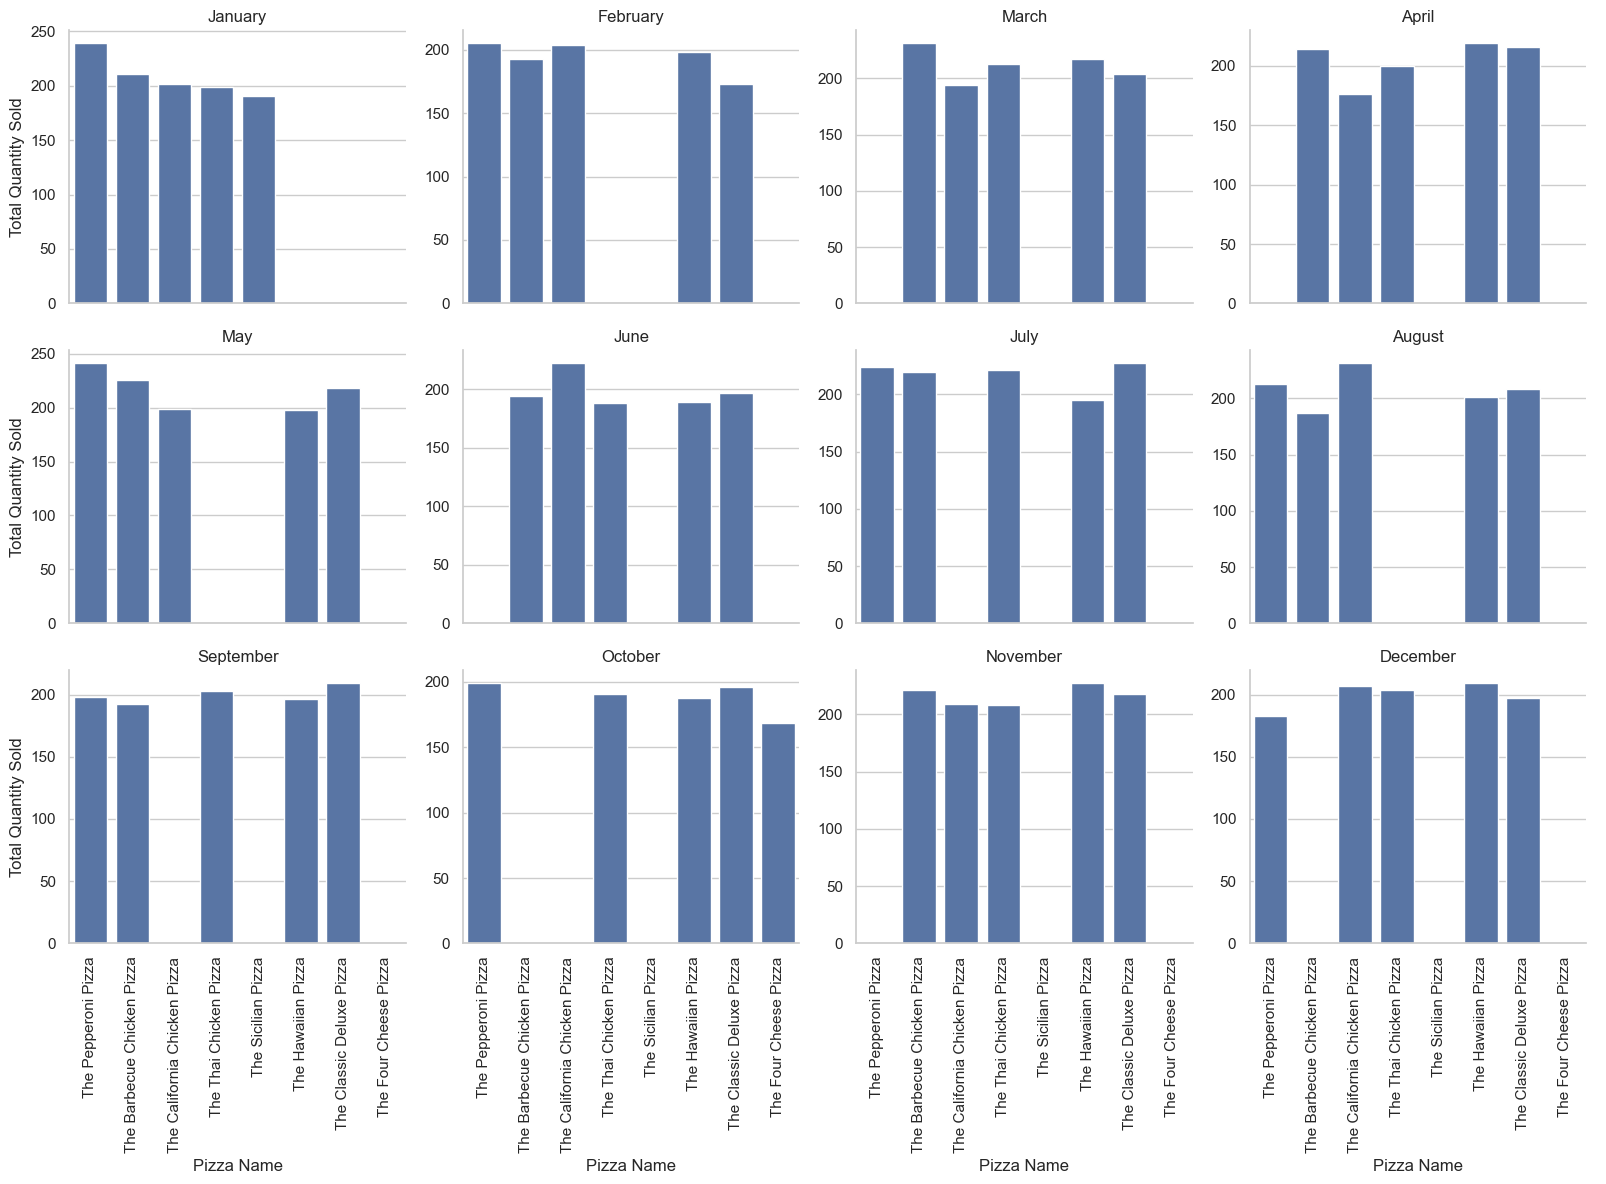

In [67]:
g = sns.catplot(
    data=top_pizzas_by_month,
    x="Pizza_name",
    y="total_quantity",
    col="month",
    col_wrap=4,
    kind="bar",
    height=4,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Pizza Name", "Total Quantity Sold")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

PIZZA SIZE TRENDS OVER TIME (ORDERS)

Plot Orders by Pizza Size Over Time

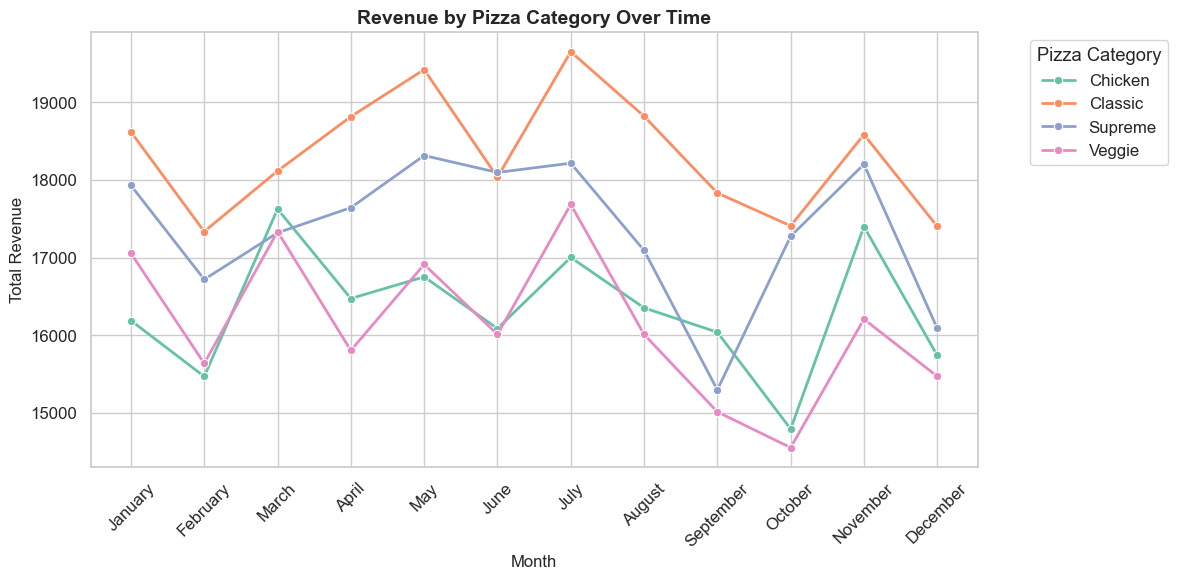

In [73]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=category_monthly,
    x="month",
    y="total_revenue",
    hue="Pizza_category",
    marker="o",
    linewidth=2
)

plt.title("Revenue by Pizza Category Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.legend(title="Pizza Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

TOP 10 PIZZAS (OVERALL) – HORIZONTAL BAR

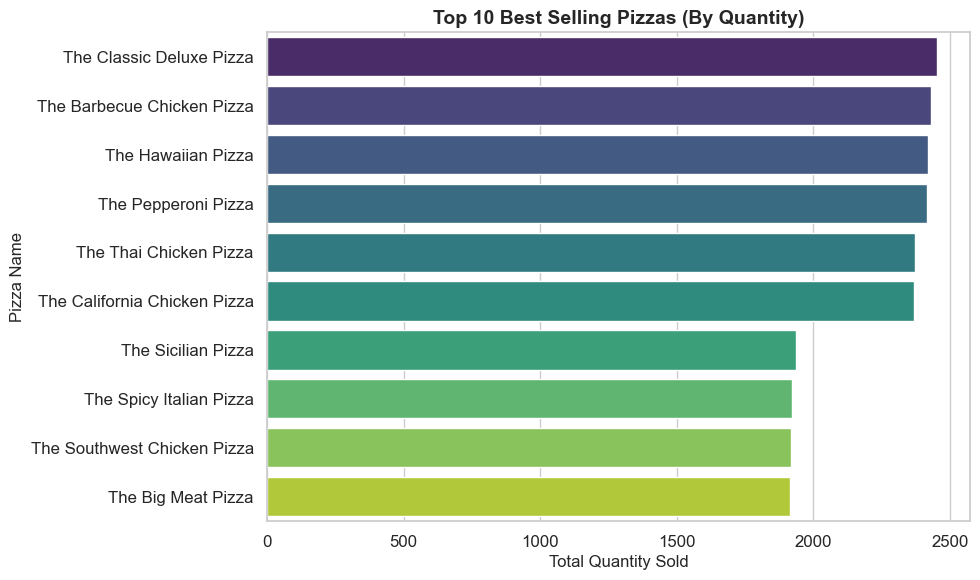

In [77]:
palette = sns.color_palette("viridis", n_colors=len(top_10_pizzas))

sns.barplot(
    data=top_10_pizzas,
    y="Pizza_name",
    x="total_quantity",
    hue="Pizza_name",
    palette=palette,
    legend=False
)

plt.title("Top 10 Best Selling Pizzas (By Quantity)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Pizza Name")

plt.tight_layout()
plt.show()

## Key Insights

- Customers purchase an average of ~2.3 pizzas per order
- Certain pizza categories exhibit strong seasonal behavior
- Medium and Large sizes dominate order volume
- Revenue concentration suggests opportunities for targeted promotions
``